In [ ]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time

BASE_URL = "https://books.toscrape.com/"
books_data = []

# Scrape exactly first 5 pages (20 books each = 100 books)
for page in range(1, 6):
    page_url = f"{BASE_URL}catalogue/page-{page}.html"
    print(f"\nScraping Page {page}...")
    response = requests.get(page_url)

    if response.status_code != 200:
        print(f"Failed to load Page {page}")
        continue

    soup = BeautifulSoup(response.text, "html.parser")
    books = soup.find_all("article", class_="product_pod")

    for book in books:
        # Get book link
        relative_url = book.find("h3").find("a")["href"]
        book_url = BASE_URL + "catalogue/" + relative_url.replace("../", "")

        # Open individual book page
        book_response = requests.get(book_url)
        if book_response.status_code != 200:
            continue
        book_soup = BeautifulSoup(book_response.text, "html.parser")

        # Title
        title = book_soup.find("div", class_="product_main").find("h1").text.strip()

        # Price
        price = book_soup.find("p", class_="price_color").text.strip()

        # Rating
        rating = book_soup.find("p", class_="star-rating")["class"][1]

        # Availability
        availability = book_soup.find("p", class_="availability").get_text(" ", strip=True)

        # Product Description
        description = ""
        description_heading = book_soup.find("div", id="product_description")

        if description_heading:
            description = description_heading.find_next_sibling("p").text.strip()

        # Product Information Table
        product_info = {}
        table = book_soup.find("table", class_="table table-striped")
        rows = table.find_all("tr")

        for row in rows:
            key = row.find("th").text.strip()
            value = row.find("td").text.strip()
            product_info[key] = value
        upc = product_info.get("UPC", "")
        reviews = product_info.get("Number of reviews", "")

        # Category
        breadcrumb = book_soup.find("ul", class_="breadcrumb").find_all("li")
        category = breadcrumb[2].text.strip()

        # Save Data
        books_data.append({
            "Title": title,
            "Category": category,
            "Price": price,
            "Rating": rating,
            "Availability": availability,
            "Product Description": description,
            "UPC": upc,
            "Number of Reviews": reviews,
            "Product URL": book_url
        })

        print(f"Scraped: {title}")
# Create DataFrame
df = pd.DataFrame(books_data)

# Save CSV
df.to_csv("books_100.csv", index=False, encoding="utf-8")

# Save JSON
df.to_json("books_100.json", orient="records", indent=4)

# Report
print("\nSCRAPING SUMMARY")
print("Total Books Scraped :", len(df))
print("Pages Scraped: 5")
print("Missing Values")
print(df.isnull().sum())
print()
print("Duplicate UPC Values :", df["UPC"].duplicated().sum())
print("\nFiles Generated:")
print("1. books_100.csv")
print("2. books_100.json")


Scraping Page 1...
Scraped: A Light in the Attic
Scraped: Tipping the Velvet
Scraped: Soumission
Scraped: Sharp Objects
Scraped: Sapiens: A Brief History of Humankind
Scraped: The Requiem Red
Scraped: The Dirty Little Secrets of Getting Your Dream Job
Scraped: The Coming Woman: A Novel Based on the Life of the Infamous Feminist, Victoria Woodhull
Scraped: The Boys in the Boat: Nine Americans and Their Epic Quest for Gold at the 1936 Berlin Olympics
Scraped: The Black Maria
Scraped: Starving Hearts (Triangular Trade Trilogy, #1)
Scraped: Shakespeare's Sonnets
Scraped: Set Me Free
Scraped: Scott Pilgrim's Precious Little Life (Scott Pilgrim #1)
Scraped: Rip it Up and Start Again
Scraped: Our Band Could Be Your Life: Scenes from the American Indie Underground, 1981-1991
Scraped: Olio
Scraped: Mesaerion: The Best Science Fiction Stories 1800-1849
Scraped: Libertarianism for Beginners
Scraped: It's Only the Himalayas

Scraping Page 2...
Scraped: In Her Wake
Scraped: How Music Works
Scraped

In [ ]:
import pandas as pd
import re


# Load dataset
df = pd.read_csv("books_100.csv")

# Fix encoding issues in Price
df['Price'] = df['Price'].str.replace("Â£", "£")

# Deduplicate by UPC
df = df.drop_duplicates(subset=['UPC'])

# Handle missing descriptions
df['Product Description'] = df['Product Description'].fillna("No description available")

# Convert Price to numeric
df['Price'] = df['Price'].str.replace("£", "").astype(float)

# Map Ratings to integers
rating_map = {"One": 1, "Two": 2, "Three": 3, "Four": 4, "Five": 5}
df['Rating'] = df['Rating'].map(rating_map)

# Extract stock count
df['Stock'] = df['Availability'].str.extract(r'(\d+)').astype(int)

# Word count of description
df['description_word_count'] = df['Product Description'].apply(lambda x: len(str(x).split()))

# Price band
df['price_band'] = pd.cut(df['Price'], bins=[0,20,40,100], labels=['Low','Medium','High'])

# Affordability score (rating/price)
df['affordability_score'] = df['Rating'] / df['Price']

# Value score (rating * reviews + stock / price)
df['value_score'] = (df['Rating'] * df['Number of Reviews'] + df['Stock']) / df['Price']

# Recommended flag
df['recommended'] = (df['Rating'] >= 4) & (df['Price'] <= 40)

# Drop Availability column
df = df.drop(columns=['Availability'])

# Save cleaned dataset
df.to_csv("books_cleaned.csv", index=False)



In [ ]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time

BASE_URL = "https://books.toscrape.com/"
books_data = []

# Scrape exactly first 5 pages (20 books each = 100 books)
for page in range(1, 6):
    page_url = f"{BASE_URL}catalogue/page-{page}.html"
    print(f"\nScraping Page {page}...")
    response = requests.get(page_url)

    if response.status_code != 200:
        print(f"Failed to load Page {page}")
        continue

    soup = BeautifulSoup(response.text, "html.parser")
    books = soup.find_all("article", class_="product_pod")

    for book in books:
        # Get book link
        relative_url = book.find("h3").find("a")["href"]
        book_url = BASE_URL + "catalogue/" + relative_url.replace("../", "")

        # Open individual book page
        book_response = requests.get(book_url)
        if book_response.status_code != 200:
            continue
        book_soup = BeautifulSoup(book_response.text, "html.parser")

        # Title
        title = book_soup.find("div", class_="product_main").find("h1").text.strip()

        # Price
        price = book_soup.find("p", class_="price_color").text.strip()

        # Rating
        rating = book_soup.find("p", class_="star-rating")["class"][1]

        # Availability
        availability = book_soup.find("p", class_="availability").get_text(" ", strip=True)

        # Product Description
        description = ""
        description_heading = book_soup.find("div", id="product_description")

        if description_heading:
            description = description_heading.find_next_sibling("p").text.strip()

        # Product Information Table
        product_info = {}
        table = book_soup.find("table", class_="table table-striped")
        rows = table.find_all("tr")

        for row in rows:
            key = row.find("th").text.strip()
            value = row.find("td").text.strip()
            product_info[key] = value
        upc = product_info.get("UPC", "")
        reviews = product_info.get("Number of reviews", "")

        # Category
        breadcrumb = book_soup.find("ul", class_="breadcrumb").find_all("li")
        category = breadcrumb[2].text.strip()

        # Save Data
        books_data.append({
            "Title": title,
            "Category": category,
            "Price": price,
            "Rating": rating,
            "Availability": availability,
            "Product Description": description,
            "UPC": upc,
            "Number of Reviews": reviews,
            "Product URL": book_url
        })

        print(f"Scraped: {title}")
# Create DataFrame
df = pd.DataFrame(books_data)

# Save CSV
df.to_csv("books_100.csv", index=False, encoding="utf-8")

# Save JSON
df.to_json("books_100.json", orient="records", indent=4)

# Report
print("\nSCRAPING SUMMARY")
print("Total Books Scraped :", len(df))
print("Pages Scraped: 5")
print("Missing Values")
print(df.isnull().sum())
print()
print("Duplicate UPC Values :", df["UPC"].duplicated().sum())
print("\nFiles Generated:")
print("1. books_100.csv")
print("2. books_100.json")


Scraping Page 1...
Scraped: A Light in the Attic
Scraped: Tipping the Velvet
Scraped: Soumission
Scraped: Sharp Objects
Scraped: Sapiens: A Brief History of Humankind
Scraped: The Requiem Red
Scraped: The Dirty Little Secrets of Getting Your Dream Job
Scraped: The Coming Woman: A Novel Based on the Life of the Infamous Feminist, Victoria Woodhull
Scraped: The Boys in the Boat: Nine Americans and Their Epic Quest for Gold at the 1936 Berlin Olympics
Scraped: The Black Maria
Scraped: Starving Hearts (Triangular Trade Trilogy, #1)
Scraped: Shakespeare's Sonnets
Scraped: Set Me Free
Scraped: Scott Pilgrim's Precious Little Life (Scott Pilgrim #1)
Scraped: Rip it Up and Start Again
Scraped: Our Band Could Be Your Life: Scenes from the American Indie Underground, 1981-1991
Scraped: Olio
Scraped: Mesaerion: The Best Science Fiction Stories 1800-1849
Scraped: Libertarianism for Beginners
Scraped: It's Only the Himalayas

Scraping Page 2...
Scraped: In Her Wake
Scraped: How Music Works
Scraped

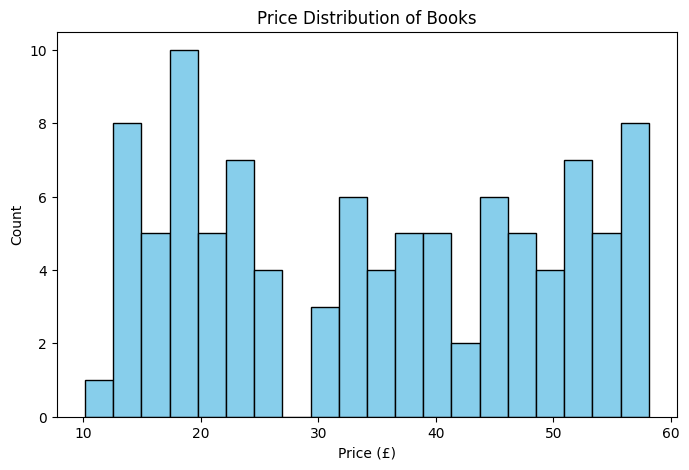

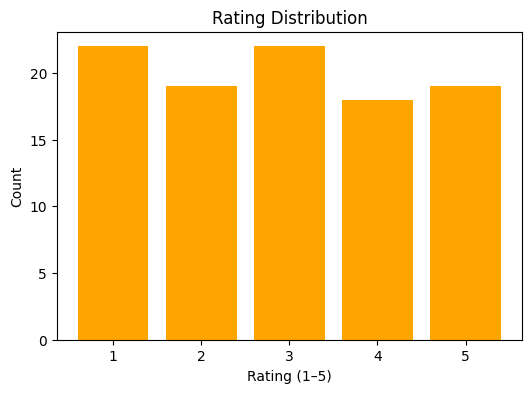

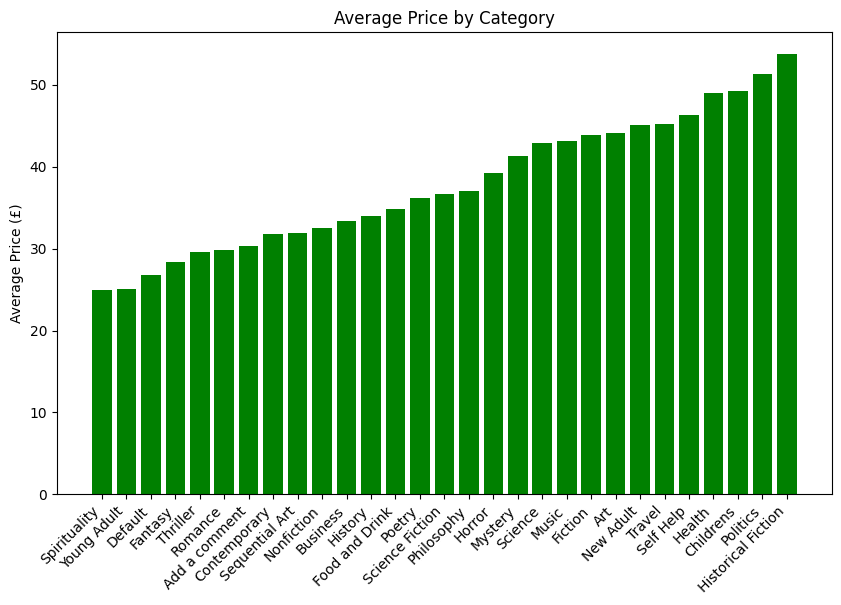

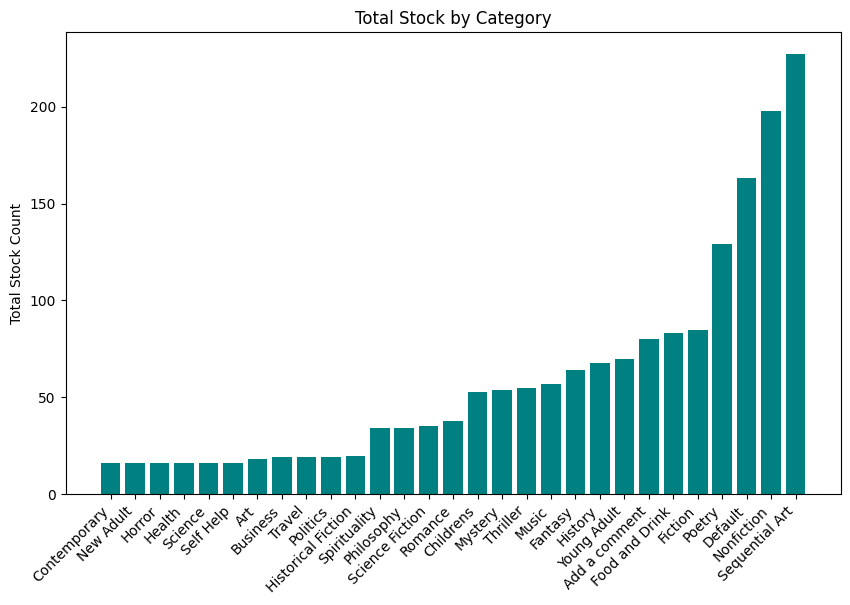

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load cleaned dataset
df = pd.read_csv("books_cleaned.csv")

# Price Distribution
plt.figure(figsize=(8,5))
plt.hist(df['Price'], bins=20, color='skyblue', edgecolor='black')
plt.title("Price Distribution of Books")
plt.xlabel("Price (£)")
plt.ylabel("Count")
plt.show()

# Rating Distribution
plt.figure(figsize=(6,4))
plt.bar(df['Rating'].value_counts().index, df['Rating'].value_counts().values, color='orange')
plt.title("Rating Distribution")
plt.xlabel("Rating (1–5)")
plt.ylabel("Count")
plt.show()

# Average Price by Category
avg_price = df.groupby('Category')['Price'].mean().sort_values()
plt.figure(figsize=(10,6))
plt.bar(avg_price.index, avg_price.values, color='green')
plt.xticks(rotation=45, ha="right")
plt.title("Average Price by Category")
plt.ylabel("Average Price (£)")
plt.show()

# Total Stock by Category
total_stock = df.groupby('Category')['Stock'].sum().sort_values()

plt.figure(figsize=(10,6))
plt.bar(total_stock.index, total_stock.values, color='teal')
plt.xticks(rotation=45, ha="right")
plt.title("Total Stock by Category")
plt.ylabel("Total Stock Count")
plt.show()


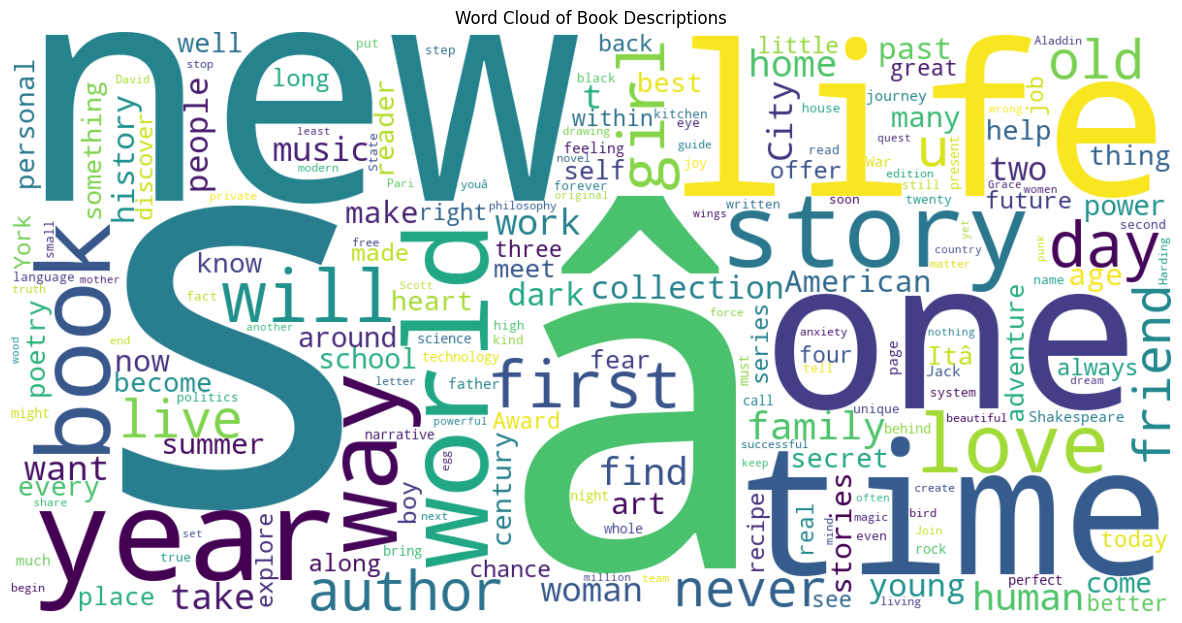

In [10]:
import pandas as pd
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Read dataset
df = pd.read_csv("books_cleaned.csv")

# Combine all descriptions
text = " ".join(df["Product Description"].dropna().astype(str))

# Generate word cloud
wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    max_words=200,
    collocations=False
).generate(text)

# Display
plt.figure(figsize=(15,8))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of Book Descriptions")
plt.show()